# AA_Cam_pose_sweeps

Sweeps camera density (target frame count, `cam_poses`) at a fixed video range (`start_3D_recon`..`end_3D_recon`) through every reconstruction technique, scores each against GPS ground truth, and pools everything into one CSV.

Process code (scoring, resumability/status tracking, disk-retention cleanup, the sweep loop itself) lives in `AA_cam_pose_sweeps.py`, next to this notebook -- import it, don't copy it, so fixes/improvements there apply to every per-case copy of this notebook automatically. This notebook only holds what varies per case:
- **Config**: `case_name`, frame range, `CAM_POSES`, `TECHNIQUE_ORDER`, `FLAGS`, and `DATA_STORAGE` (what to keep on disk afterwards vs delete).
- **Part 2 (Sweep)** is expensive (minutes per technique per density) and resumable -- safe to interrupt/kill and re-run from the top. GPU OOM kills the whole kernel outright (not a catchable Python exception), so the resumability design is disk-based, not in-process -- see `AA_cam_pose_sweeps.py`'s Resumability infrastructure section.
- **Part 3 (Load + plot)** is cheap -- it only reads the pooled CSV off disk, so the chart can be restyled/re-run any number of times without re-touching the sweep. Stays notebook-side since it's meant to be freely tweaked per case.

`align_and_score` and the trace loaders are reused from `F_post_recon_processing.py`/`AA_cam_pose_sweeps.py`, same functions `AA_Cam_pose_estimate_batches.ipynb` uses.

In [1]:
%load_ext autoreload
%autoreload 2

## Config

In [15]:
import sys
from pathlib import Path

# Find the repo root by walking up until we hit src/A_Config.py -- see
# AA_Cam_pose_estimate_batches.ipynb for why this is more robust than Path.cwd().parent.
project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
sys.path.insert(0, str(project_root / "Experiments" / "templates"))
print("project_root:", project_root)

from A_Config import set_case, case_dir
from Two2D.B_video_processing import video_fps
from templates.AA_cam_pose_sweeps import reset_sweep_state, run_density_sweep

case_name = "401_Hide_n_seek"
experiment = "Cam_pose_dist_v1"
set_case(case_name, experiment)  # must happen before any case_dir()/A_Config getter call below

source_dir   = case_dir() / "010_source"
videos = list(source_dir.glob("*.mp4"))
video_path = videos[0]

import cv2; total_frames = int(cv2.VideoCapture(str(video_path)).get(cv2.CAP_PROP_FRAME_COUNT))
print("total_frames",total_frames )
# Fixed video range -- only the frame DENSITY within this range varies across the sweep.
# Hardcoded per AI_coppertest3_vggt.ipynb's precedent (no reusable start/end-frame config exists yet).

start_3D_recon = 975
interframe_interval = 38
max_dur = interframe_interval*201+start_3D_recon
n_steps = 10
step = interframe_interval * (200 // n_steps)
print(step)
end_3D_recon_list = []
dur = interframe_interval
while start_3D_recon + dur < max_dur:
    end_3D_recon_list.append(start_3D_recon + dur)
    dur *= 2
end_3D_recon_list.append(max_dur)
print("doubler",end_3D_recon_list)

#end_3D_recon_list = range((25*interval)+ start_3D_recon, max_dur, interval * (200 // n_steps))

end_3D_recon_list = list(range(start_3D_recon + step, max_dur, step))
print(end_3D_recon_list)
fps = video_fps(video_path)
print(f"video fps: {fps:.3f}")
print("max frames in recon", max_dur-start_3D_recon)
# Target frame counts to sweep, ascending -- ascending order matters for the
# OOM-precaution logic in run_density_sweep (more frames -> more GPU memory).
#CAM_POSES = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250,275,300]

# Fixed run order (user-specified) -- cheapest/most-reliable techniques first.
TECHNIQUE_ORDER = ["CUT3R","CUT3R_Revisit", "lingbot-map", "VGGT-Omega", "MegaSaM", "VGGT"]

# Which techniques are actually enabled -- same defaults as AA_Cam_pose_estimate_batches.ipynb.
FLAGS = {
     "CUT3R":       False,
    "CUT3R_Revisit": False,
    "lingbot-map": False,
    "VGGT-Omega":  True,
    "MegaSaM":     False,
    "VGGT":        False,
}

# What the sweep keeps on disk afterwards vs deletes -- see AA_cam_pose_sweeps.py's
# _cleanup_technique_output for exactly what each toggle controls.
DATA_STORAGE = {
    "keep_inputs":     True,  # extracted frames per density (020_frames_for_cam_poses)
    "keep_recon_data": True,  # full heavy technique output (images/depth/point-clouds/caches)
    "keep_cam_poses":  True,   # lightweight <technique_output>/CAM_poses/poses.csv per density
    "full_pose":       True,  # rotation too, not just translation, in the retained CSV
    "render_bev":      True,   # one <technique_output>/BEV/bev.png per technique/density --
                                # every technique gets a Reconstruction (natively for VGGT-Omega,
                                # via F_transpose_to_recon_objects.py adapters for the rest), then
                                # P_projection_mapping.BEV_tile_render_PM renders from it. Cheap
                                # to keep even when keep_recon_data=False.
}
out_dir = case_dir() / "080_Experiments"
out_dir.mkdir(parents=True, exist_ok=True)

project_root: /workspace/project
total_frames 7655
760
doubler [1013, 1051, 1127, 1279, 1583, 2191, 3407, 5839, 8613]
[1735, 2495, 3255, 4015, 4775, 5535, 6295, 7055, 7815, 8575]
video fps: 30.000
max frames in recon 7638


## Reset sweep state

Deletes **only** this sweep's own output -- everything from running this sweep, nothing more, nothing less: every `poses_*` frame/reconstruction folder under the `experiment` tag defined above, plus the status/results CSVs. Nothing from `AA_Cam_pose_estimate_batches.ipynb` (different experiment name) or anything else in the case directory is touched.

Safe by default: with `CONFIRM_DELETE = False` this only prints what it *would* delete. Flip it to `True` and re-run the cell to actually delete.

In [16]:
CONFIRM_DELETE = False  # flip to True and re-run this cell to actually delete

reset_sweep_state(case_name, experiment, confirm=CONFIRM_DELETE)

confirm=False -- dry run only, nothing deleted. Would remove:
  rmtree /workspace/project/Data/401_Hide_n_seek/020_frames_for_cam_poses/Cam_pose_dist_v1
  rmtree /workspace/project/Data/401_Hide_n_seek/080_Experiments/Cam_pose_dist_v1


## Ground truth

Same manual GT loading as `AA_Cam_pose_estimate_batches.ipynb` -- see that notebook for the naming-convention caveat.

In [17]:
from Q_GPS_processing import csv_to_GPS_dict

gt_csv_path = case_dir() / "000_GPS_Data" / "GPS_tags.csv"
GPS_dict = csv_to_GPS_dict(gt_csv_path)
print(f"{len(GPS_dict)} GT anchors loaded from {gt_csv_path.name}")

39 GT anchors loaded from GPS_tags.csv


## Part 2 -- Sweep (expensive, resumable, run once/rarely)

`run_density_sweep` (in `AA_cam_pose_sweeps.py`) gives each `cam_poses` value its own frames/output folders via a nested experiment tag (`f"{experiment}/poses_{cam_poses:04d}"` passed to `set_case`) -- this makes every `A_Config` getter (including `run_lingbot_map`'s, which has no path parameters at all and only reads the zero-arg getters) automatically density-scoped, with no per-function path-wrangling needed.

Safe to interrupt/kill and re-run from the top at any point.

In [18]:
from AA_cam_pose_sweeps import run_distance_sweep
run_distance_sweep(
    case_name, experiment, video_path, start_3D_recon, end_3D_recon_list,interframe_interval,
     TECHNIQUE_ORDER, FLAGS, DATA_STORAGE, project_root, GPS_dict,
)

[CUT3R @ 1735] kernel died mid-attempt last run -- presumed GPU OOM (restart the kernel now if you haven't already)
[CUT3R @ 2495] precautionary skip (OOM upstream at cam_poses=1735)
[CUT3R @ 3255] precautionary skip (OOM upstream at cam_poses=1735)
[CUT3R @ 4015] precautionary skip (OOM upstream at cam_poses=1735)
[CUT3R @ 4775] precautionary skip (OOM upstream at cam_poses=1735)
[CUT3R @ 5535] precautionary skip (OOM upstream at cam_poses=1735)
[CUT3R @ 6295] precautionary skip (OOM upstream at cam_poses=1735)
[CUT3R @ 7055] precautionary skip (OOM upstream at cam_poses=1735)
[CUT3R @ 7815] precautionary skip (OOM upstream at cam_poses=1735)
[CUT3R @ 8575] precautionary skip (OOM upstream at cam_poses=1735)
end frame =1735: frames already present in /workspace/project/Data/401_Hide_n_seek/020_frames_for_cam_poses/Cam_pose_dist_v1/poses_1735, skipping extraction
20 frames  →  /workspace/project/Data/401_Hide_n_seek/035_VGGT_O_output/Cam_pose_dist_v1/poses_1735
GPU freed -- 0.01 GiB st

Pass 1: scoring: 100%|██████████| 1520/1520 [00:05<00:00, 253.51fr/s]


Selected: 40 frames  (33 shifted from sample point, 0 skipped below threshold)


Pass 3: writing: 100%|██████████| 1520/1520 [00:03<00:00, 475.09fr/s]


Log     : /workspace/project/Data/401_Hide_n_seek/020_frames_for_cam_poses/Cam_pose_dist_v1/poses_2495/selection_log.json
Sharpness (at 25% res): min 1799 · mean 6573 · max 15654
40 frames  →  /workspace/project/Data/401_Hide_n_seek/035_VGGT_O_output/Cam_pose_dist_v1/poses_2495
GPU freed -- 0.01 GiB still allocated, 0.02 GiB reserved
Saved: /workspace/project/Data/401_Hide_n_seek/035_VGGT_O_output/Cam_pose_dist_v1/poses_2495/predictions.npz
Saved: /workspace/project/Data/401_Hide_n_seek/035_VGGT_O_output/Cam_pose_dist_v1/poses_2495/scene.glb
min depth tensor(0.0257, device='cuda:0')
torch.Size([10567679, 3])
mins, maxes and ranges -2.753710353374481 2.6846550345420837 5.438365387916565 -1.5034325420856476 1.5268982946872711 3.0303308367729187
scale - original 800.7751587036439
min depth tensor(0.0257, device='cuda:0')
torch.Size([10039295, 3])
mins, maxes and ranges -1.207564541697502 1.0589414924383163 2.2665060341358183 -1.4773007541894914 0.9781307488679886 2.45543150305748
scale - 

...

Log     : /workspace/project/Data/401_Hide_n_seek/020_frames_for_cam_poses/Cam_pose_dist_v1/poses_7815/selection_log.json
Sharpness (at 25% res): min 261 · mean 4794 · max 18948
176 frames  →  /workspace/project/Data/401_Hide_n_seek/035_VGGT_O_output/Cam_pose_dist_v1/poses_7815
GPU freed -- 0.01 GiB still allocated, 0.02 GiB reserved
Saved: /workspace/project/Data/401_Hide_n_seek/035_VGGT_O_output/Cam_pose_dist_v1/poses_7815/predictions.npz
Saved: /workspace/project/Data/401_Hide_n_seek/035_VGGT_O_output/Cam_pose_dist_v1/poses_7815/scene.glb
min depth tensor(0.0190, device='cuda:0')
torch.Size([46497786, 3])
mins, maxes and ranges -6.143772780895233 3.62105792760849 9.764830708503723 -8.627894711494445 5.355198693275452 13.983093404769896
scale - original 583.5554758451764
min depth tensor(0.0190, device='cuda:0')
torch.Size([44172902, 3])
mins, maxes and ranges -4.397558546066284 2.0195735454559327 6.417132091522216 -4.028744238615036 1.7839492738246918 5.812693512439727
scale - origi

Pass 1: scoring: 100%|██████████| 6680/6680 [00:25<00:00, 262.42fr/s]


Selected: 176 frames  (123 shifted from sample point, 0 skipped below threshold)


Pass 3: writing: 100%|██████████| 6680/6680 [00:13<00:00, 495.88fr/s]


Log     : /workspace/project/Data/401_Hide_n_seek/020_frames_for_cam_poses/Cam_pose_dist_v1/poses_8575/selection_log.json
Sharpness (at 25% res): min 261 · mean 4794 · max 18948
176 frames  →  /workspace/project/Data/401_Hide_n_seek/035_VGGT_O_output/Cam_pose_dist_v1/poses_8575
GPU freed -- 0.01 GiB still allocated, 0.02 GiB reserved
Saved: /workspace/project/Data/401_Hide_n_seek/035_VGGT_O_output/Cam_pose_dist_v1/poses_8575/predictions.npz
Saved: /workspace/project/Data/401_Hide_n_seek/035_VGGT_O_output/Cam_pose_dist_v1/poses_8575/scene.glb
min depth tensor(0.0190, device='cuda:0')
torch.Size([46497786, 3])
mins, maxes and ranges -6.143772780895233 3.62105792760849 9.764830708503723 -8.627894711494445 5.355198693275452 13.983093404769896
scale - original 583.5554758451764
min depth tensor(0.0190, device='cuda:0')
torch.Size([44172902, 3])
mins, maxes and ranges -4.397558546066284 2.0195735454559327 6.417132091522216 -4.028744238615036 1.7839492738246918 5.812693512439727
scale - origi

## Part 3 -- Load + plot (cheap, re-runnable independently)

Reads `density_sweep_results.csv` fresh from disk -- does not depend on Part 2 having just run, so this cell can be re-run/restyled any number of times without touching the sweep. Colour mapping matches the informal `tab10`-by-insertion-order precedent in `AA_CAM_POSE_COMPARE_01.ipynb` cell 25 (`lingbot_map`, `VGGT_O`, `CUT3R`, `MegaSaM` kept at their original slots; `VGGT` plain wasn't in that precedent, so it reuses the freed `Reality_Scan` slot).

# line

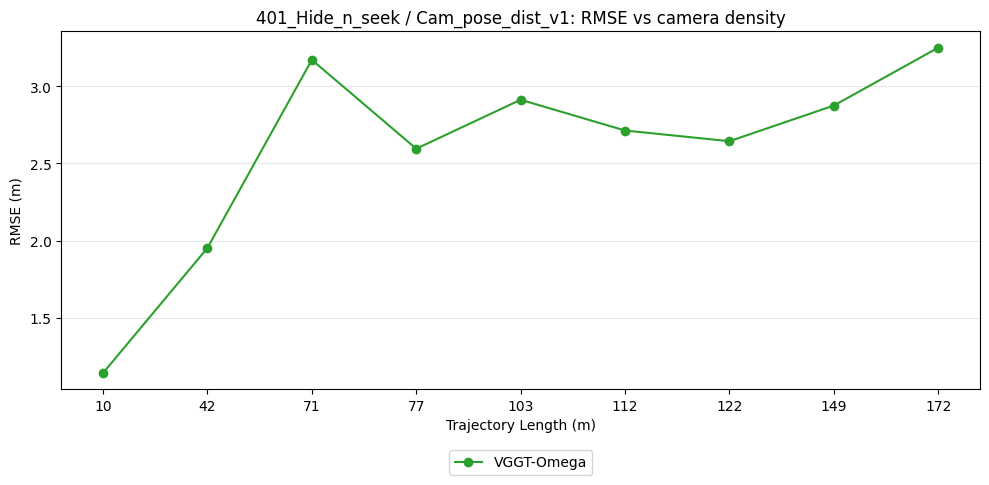

In [22]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
from A_Config import set_case, case_dir



set_case(case_name, experiment)
results_path = case_dir() / "080_Experiments" / f"{experiment}" / f"{experiment}_results.csv"

TECHNIQUE_ORDER = ["CUT3R", "lingbot-map", "VGGT-Omega", "MegaSaM", "VGGT"]
TECHNIQUE_ORDER = ["VGGT-Omega"]
tab10 = plt.cm.tab10.colors
COLOR_MAP = {
    "lingbot-map": tab10[0],
    "VGGT":        tab10[1],  # no precedent for plain VGGT -- reuses the freed Reality_Scan slot
    "VGGT-Omega":  tab10[2],
    "CUT3R":       tab10[3],
    "MegaSaM":     tab10[4],
    
}

df = pd.read_csv(results_path)
techniques = [t for t in TECHNIQUE_ORDER if t in df["technique"].unique()]
cam_poses_vals = sorted(df["trajectory length (m)"].unique())

x = np.arange(len(cam_poses_vals))

fig, ax = plt.subplots(figsize=(10, 5))
for technique in techniques:
    sub = df[df["technique"] == technique].set_index("trajectory length (m)")["rmse"]
    heights = [sub.get(cp, np.nan) for cp in cam_poses_vals]
    ax.plot(x, heights, marker="o", label=technique, color=COLOR_MAP.get(technique))

ax.set_xticks(x)
ax.set_xticklabels([f"{v:.0f}" for v in cam_poses_vals])
ax.set_xlabel("Trajectory Length (m)")
ax.set_ylabel("RMSE (m)")
ax.set_title(f"{case_name} / {experiment}: RMSE vs camera density")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=len(techniques))
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(out_dir / f"{case_name}_{experiment}_RMSE_distance.svg", format="svg", bbox_inches="tight")